In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
df = pd.read_csv('../data/heart.csv')
print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()

Dataset carregado: 1025 linhas e 14 colunas


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("=== INFORMAÇÕES GERAIS ===")
print(df.info())
print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
df.describe()

=== INFORMAÇÕES GERAIS ===
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

=== ESTATÍSTICAS DESCRITIVAS ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
print("=== VERIFICAÇÃO DE QUALIDADE DOS DADOS ===")

# 1. Valores nulos
print("\n📋 Valores nulos por coluna:")
print(df.isnull().sum())

# 2. Linhas duplicadas
duplicatas = df.duplicated().sum()
print(f"\n🔁 Linhas duplicadas: {duplicatas}")

# 3. Valores negativos em colunas que não deveriam ter
colunas_positivas = ['age', 'trestbps', 'chol', 'thalach']
print("\n⚠️ Valores negativos ou zero em colunas críticas:")
for col in colunas_positivas:
    problemas = df[df[col] <= 0].shape[0]
    print(f"  {col}: {problemas} problema(s)")

# 4. Resumo geral
print("\n✅ Resumo de qualidade:")
print(f"  Total de registros: {df.shape[0]}")
print(f"  Total de colunas: {df.shape[1]}")
print(f"  Registros com algum nulo: {df.isnull().any(axis=1).sum()}")

=== VERIFICAÇÃO DE QUALIDADE DOS DADOS ===

📋 Valores nulos por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

🔁 Linhas duplicadas: 723

⚠️ Valores negativos ou zero em colunas críticas:
  age: 0 problema(s)
  trestbps: 0 problema(s)
  chol: 0 problema(s)
  thalach: 0 problema(s)

✅ Resumo de qualidade:
  Total de registros: 1025
  Total de colunas: 14
  Registros com algum nulo: 0


In [5]:
print(f"Registros antes da limpeza: {df.shape[0]}")

# Remove duplicatas
df_clean = df.drop_duplicates()

print(f"Registros após limpeza: {df_clean.shape[0]}")
print(f"Duplicatas removidas: {df.shape[0] - df_clean.shape[0]}")

Registros antes da limpeza: 1025
Registros após limpeza: 302
Duplicatas removidas: 723


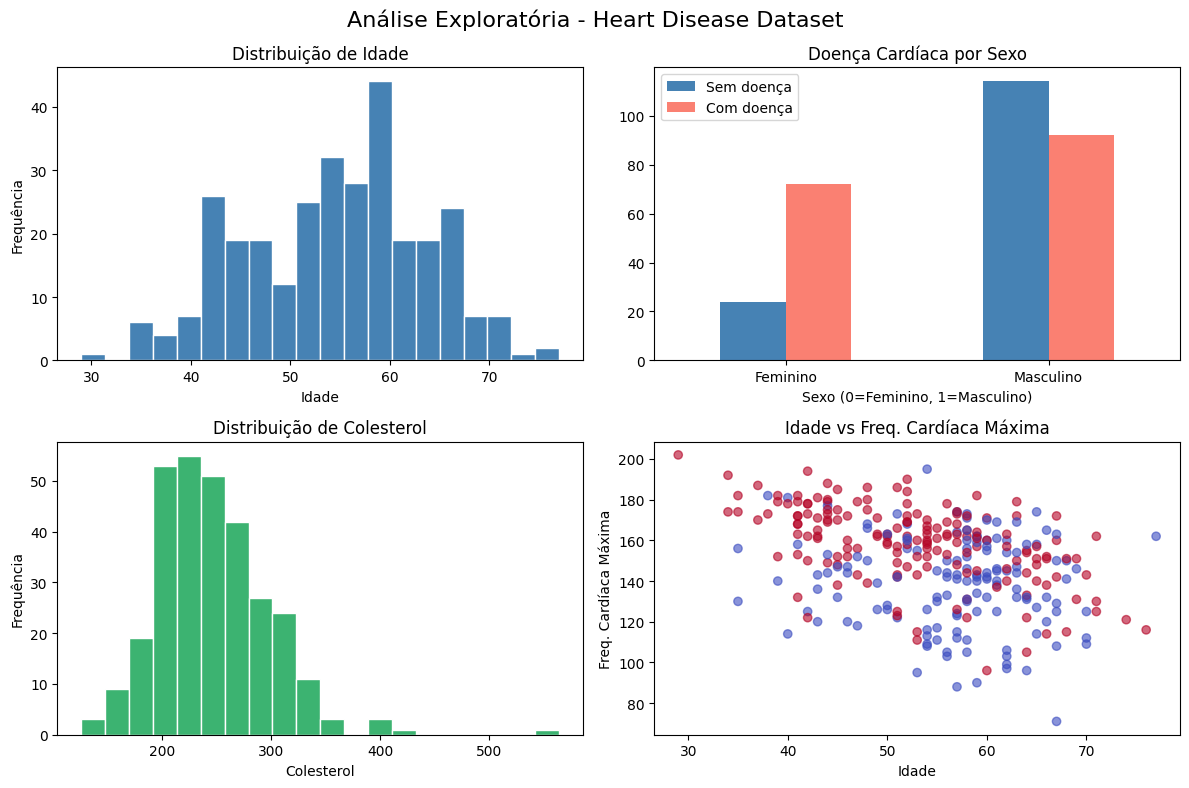

Gráfico salvo em reports/


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Análise Exploratória - Heart Disease Dataset', fontsize=16)

# 1. Distribuição de idade
axes[0, 0].hist(df_clean['age'], bins=20, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribuição de Idade')
axes[0, 0].set_xlabel('Idade')
axes[0, 0].set_ylabel('Frequência')

# 2. Doença cardíaca por sexo
sexo_target = df_clean.groupby(['sex', 'target']).size().unstack()
sexo_target.plot(kind='bar', ax=axes[0, 1], color=['steelblue', 'salmon'])
axes[0, 1].set_title('Doença Cardíaca por Sexo')
axes[0, 1].set_xlabel('Sexo (0=Feminino, 1=Masculino)')
axes[0, 1].set_xticklabels(['Feminino', 'Masculino'], rotation=0)
axes[0, 1].legend(['Sem doença', 'Com doença'])

# 3. Distribuição de colesterol
axes[1, 0].hist(df_clean['chol'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Distribuição de Colesterol')
axes[1, 0].set_xlabel('Colesterol')
axes[1, 0].set_ylabel('Frequência')

# 4. Idade vs Frequência Cardíaca Máxima
axes[1, 1].scatter(df_clean['age'], df_clean['thalach'], 
                   c=df_clean['target'], cmap='coolwarm', alpha=0.6)
axes[1, 1].set_title('Idade vs Freq. Cardíaca Máxima')
axes[1, 1].set_xlabel('Idade')
axes[1, 1].set_ylabel('Freq. Cardíaca Máxima')

plt.tight_layout()
plt.savefig('../reports/analise_exploratoria.png', dpi=150)
plt.show()
print("Gráfico salvo em reports/")

In [7]:
print("=" * 50)
print("RELATÓRIO DE QUALIDADE DE DADOS")
print("=" * 50)
print(f"""
📁 Dataset: Heart Disease (UCI)
📊 Registros originais: 1025
🔁 Duplicatas encontradas: 723 (70.5%)
✅ Registros após limpeza: 302
❌ Valores nulos: 0
⚠️  Valores inválidos: 0

CONCLUSÃO:
O dataset apresentou problema crítico de duplicação
de dados (70.5% dos registros). Após tratamento,
restaram 302 registros válidos para análise.

Os dados limpos mostram distribuição adequada para
modelagem preditiva de doenças cardíacas.
""")
print("=" * 50)

RELATÓRIO DE QUALIDADE DE DADOS

📁 Dataset: Heart Disease (UCI)
📊 Registros originais: 1025
🔁 Duplicatas encontradas: 723 (70.5%)
✅ Registros após limpeza: 302
❌ Valores nulos: 0
⚠️  Valores inválidos: 0

CONCLUSÃO:
O dataset apresentou problema crítico de duplicação
de dados (70.5% dos registros). Após tratamento,
restaram 302 registros válidos para análise.

Os dados limpos mostram distribuição adequada para
modelagem preditiva de doenças cardíacas.

